# Quantum Extreme Learning Machines and the XOR Problem

This notebook is self-contained. It builds a *quantum extreme learning machine*
(QELM) that solves the classic XOR classification problem, and isolates the role
of the fixed quantum dynamics through a raw-vs-QELM ablation.

**The QELM idea.** A quantum extreme learning machine keeps training trivial and
lets the physics do the hard part. Classical data is written into a fixed quantum
state, that state is pushed through a fixed, *untrained* scrambling unitary, and a
bank of local observables is measured. Only a linear readout on those measured
expectation values is fit. The quantum dynamics supply the nonlinearity; the
learning step stays a plain linear model.

## Motivation: XOR is not linearly separable

The XOR (exclusive-or) problem is the textbook example of a task a linear model
cannot solve. In its continuous form the two input coordinates $(x_1, x_2)$ carry
the label
$$
y = \mathrm{sign}(x_1 x_2),
$$
so the positive class occupies the two quadrants where $x_1$ and $x_2$ share a
sign, and the negative class occupies the other two. The classes interlock in a
checkerboard. No straight line separates a checkerboard, so a linear classifier on
the raw inputs $(x_1, x_2)$ is stuck at chance.

**The feature-map fix.** A linear model fails only in the *raw* coordinates. If we
first map each input through a fixed nonlinear feature map $x \mapsto f(x)$ into a
higher-dimensional feature space, a task that was not linearly separable can become
linearly separable there. Learning then reduces to fitting a hyperplane in feature
space, which is a linear problem again. The whole difficulty moves into the choice
of feature map.

**The quantum feature map.** A QELM realizes the feature map with quantum dynamics.
We angle-encode $(x_1, x_2)$ into a small qubit register, evolve under one fixed
nonintegrable Hamiltonian, and read a set of low-weight Pauli expectation values.
The scrambling dynamics mix the two coordinates into every qubit, so single-qubit
observables become genuinely two-coordinate nonlinear functions, including the
$x_1 x_2$ product that XOR needs. None of this pipeline is trained: only the final
linear readout is.

## Problem statement

1. Sample a continuous XOR dataset: four Gaussian clusters near $(\pm 1, \pm 1)$,
   labelled $y = \mathrm{sign}(x_1 x_2)$.
2. Fix a quantum feature map: angle-encode $(x_1, x_2)$ into $N=4$ qubits, apply a
   fixed scrambling unitary $U = e^{-i H t}$ with $H$ the nonintegrable mixed-field
   Ising chain, and read the weight-one Pauli bank $\{\langle X_i\rangle,
   \langle Y_i\rangle, \langle Z_i\rangle\}$.
3. Train a single linear classifier (logistic regression) three ways and compare:
   - on the **raw** inputs $(x_1, x_2)$;
   - on the Pauli features of the **bare** (unscrambled) encoded state;
   - on the Pauli features **after** the fixed scrambling $U$ (the QELM).

The expected outcome: raw $\approx 50\%$, bare $\approx 50\%$, QELM $\approx 100\%$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from scipy.linalg import expm
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(0)

## The dataset

Four isotropic Gaussian clusters, one per quadrant, with label $y=\mathrm{sign}(x_1 x_2)$.
The clusters on the main diagonal are one class; the clusters on the anti-diagonal
are the other. This is the continuous XOR / checkerboard.

In [2]:
def make_xor(rng, n_per=120, noise=0.35):
    centers = [(1.0, 1.0), (1.0, -1.0), (-1.0, 1.0), (-1.0, -1.0)]
    XY, y = [], []
    for (cx, cy) in centers:
        XY.append(rng.normal([cx, cy], noise, size=(n_per, 2)))
        y += [1 if cx * cy > 0 else 0] * n_per   # class 1 = sign(x1 x2) > 0
    XY, y = np.vstack(XY), np.array(y)
    idx = rng.permutation(len(y))
    return XY[idx], y[idx]

XY, y = make_xor(rng)
ntr = int(0.6 * len(y))
XY_tr, y_tr, XY_te, y_te = XY[:ntr], y[:ntr], XY[ntr:], y[ntr:]
print("dataset:", XY.shape, " train/test:", ntr, len(y) - ntr)

dataset: (480, 2)  train/test: 288 192


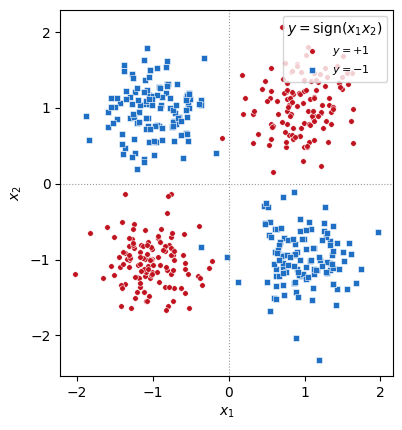

In [3]:
C_POS, C_NEG = "#c1121f", "#1f6fc4"
fig, ax = plt.subplots(figsize=(4.6, 4.4))
for lab, col, mk in [(1, C_POS, "o"), (0, C_NEG, "s")]:
    m = y == lab
    ax.scatter(XY[m, 0], XY[m, 1], s=16, color=col, marker=mk,
               edgecolors="white", linewidths=0.4,
               label=r"$y=+1$" if lab == 1 else r"$y=-1$")
ax.axhline(0, color="0.6", lw=0.8, ls=":"); ax.axvline(0, color="0.6", lw=0.8, ls=":")
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$"); ax.set_aspect("equal", "box")
ax.legend(loc="upper right", fontsize=8, title=r"$y=\mathrm{sign}(x_1 x_2)$")
plt.tight_layout(); plt.show()

A straight line can peel off at most one cluster from the rest, never the two
diagonal clusters together. This is the non-separability we have to defeat.

## The quantum feature map

**Encoding.** We use $N=4$ qubits. Qubits $0,1$ carry $x_1$ and qubits $2,3$ carry
$x_2$, each through a single-qubit rotation
$$
R_y(\alpha x)\,|0\rangle = \cos\tfrac{\alpha x}{2}\,|0\rangle
                          + \sin\tfrac{\alpha x}{2}\,|1\rangle .
$$
On this product state a single-qubit measurement gives $\langle Z\rangle=\cos(\alpha x)$,
$\langle X\rangle=\sin(\alpha x)$, $\langle Y\rangle=0$, all functions of **one**
coordinate. The bare encoded state therefore has no $x_1 x_2$ cross term to read
out from any single qubit.

**Scrambling.** The fixed feature map is one step of evolution under the
nonintegrable mixed-field Ising Hamiltonian
$$
H = J\sum_i Z_i Z_{i+1} + h_x\sum_i X_i + h_z\sum_i Z_i .
$$
The longitudinal field $h_z$ breaks the Jordan-Wigner integrability of the pure
transverse-field model, so $U = e^{-i H t}$ scrambles: it entangles the qubits and
spreads each encoded coordinate over the whole register. After $U$, a single-qubit
observable $\langle Z_i\rangle$ is a function of **both** $x_1$ and $x_2$, and its
Taylor expansion contains the product $x_1 x_2$. That product is exactly the
feature XOR requires.

**Readout.** We measure the weight-one Pauli bank $\{\langle X_i\rangle,
\langle Y_i\rangle, \langle Z_i\rangle\}_{i=0}^{N-1}$, giving a $3N=12$-dimensional
feature vector $f(x_1, x_2)$.

In [4]:
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

def kron_op(single, site, N):
    op = np.array([[1.0]], dtype=complex)
    for j in range(N):
        op = np.kron(op, single if j == site else I2)
    return op

def mixed_field_ising(N, J, hx, hz):
    H = np.zeros((2 ** N, 2 ** N), dtype=complex)
    for i in range(N - 1):
        H += J * (kron_op(Z, i, N) @ kron_op(Z, i + 1, N))
    for i in range(N):
        H += hx * kron_op(X, i, N) + hz * kron_op(Z, i, N)
    return H

QUBIT_COORD = [0, 0, 1, 1]   # qubits 0,1 -> x1 ; qubits 2,3 -> x2

def encode(x1, x2, N, alpha):
    coords = (x1, x2)
    psi = np.array([1.0], dtype=complex)
    for j in range(N):
        th = alpha * coords[QUBIT_COORD[j]]
        psi = np.kron(psi, np.array([np.cos(th / 2), np.sin(th / 2)], dtype=complex))
    return psi

The Pauli bank is precomputed as index/weight arrays: for a pure state
$\psi$, a Pauli $P = i^{p} X^{x} Z^{z}$ has
$\langle P\rangle = \mathrm{Re}\sum_b \overline{\psi_b}\, W_b\, \psi_{b\oplus x}$,
an $O(2^N)$ contraction. We check it against the brute-force $\langle\psi|P|\psi\rangle$.

In [5]:
_POP = np.array([bin(i).count("1") for i in range(1 << 16)])
_PH = np.array([1, 1j, -1, -1j])

def pauli_readout(N):
    bit = lambda i: 1 << (N - 1 - i)
    specs, names = [], []
    for i in range(N):
        specs += [(bit(i), 0, 0), (bit(i), bit(i), 1), (0, bit(i), 0)]  # X, Y, Z
        names += [f"X{i}", f"Y{i}", f"Z{i}"]
    b = np.arange(1 << N)
    COLS = np.array([b ^ x for (x, z, p) in specs])
    W = np.array([_PH[p] * (1 - 2 * (_POP[z & b] & 1)) for (x, z, p) in specs],
                 dtype=complex)
    return COLS, W, names

# sanity check the fast readout against brute force
N = 4
COLS, W, names = pauli_readout(N)
psi = encode(0.7, -1.1, N, 1.0)
fast = np.real(np.conj(psi) * W * psi[COLS]).sum(axis=1)
brute = [np.real(psi.conj() @ (kron_op({'X': X, 'Y': Y, 'Z': Z}[nm[0]], int(nm[1]), N) @ psi))
         for nm in names]
print("max |fast - brute| =", np.max(np.abs(fast - np.array(brute))))

max |fast - brute| = 1.1102230246251565e-16


In [6]:
def qelm_features(XY, N, U, COLS, W, alpha):
    F = np.zeros((len(XY), COLS.shape[0]))
    for n, (x1, x2) in enumerate(XY):
        psi = encode(x1, x2, N, alpha)
        if U is not None:
            psi = U @ psi
        F[n] = np.real(np.conj(psi) * W * psi[COLS]).sum(axis=1)
    return F

J, HX, HZ = 1.0, 0.9, 0.8   # nonintegrable mixed-field Ising scrambler
T_EV = 2.0                  # fixed scrambling time (untrained)
ALPHA = 1.0                 # angle-encoding scale
H = mixed_field_ising(N, J, HX, HZ)
U = expm(-1j * H * T_EV)    # the fixed, untrained feature-map unitary
print("U is unitary:", np.allclose(U.conj().T @ U, np.eye(2 ** N)))

U is unitary: True


## The ablation

The same logistic-regression classifier is fit three ways. Only the input features
change: raw coordinates, bare-encoding Pauli features, and QELM Pauli features. The
quantum pipeline is never trained; only the linear readout weights are.

In [7]:
def fit_score(F_tr, y_tr, F_te, y_te, C=10.0):
    clf = LogisticRegression(max_iter=5000, C=C).fit(F_tr, y_tr)
    return clf, float(clf.score(F_te, y_te))

# (1) raw inputs
raw_clf, acc_raw = fit_score(XY_tr, y_tr, XY_te, y_te)

# (2) bare encoding, no scrambling (U = None)
Fb_tr = qelm_features(XY_tr, N, None, COLS, W, ALPHA)
Fb_te = qelm_features(XY_te, N, None, COLS, W, ALPHA)
_, acc_bare = fit_score(Fb_tr, y_tr, Fb_te, y_te)

# (3) QELM: same features after the fixed scrambling U
Fs_tr = qelm_features(XY_tr, N, U, COLS, W, ALPHA)
Fs_te = qelm_features(XY_te, N, U, COLS, W, ALPHA)
qelm_clf, acc_qelm = fit_score(Fs_tr, y_tr, Fs_te, y_te)

print(f"raw-linear   test accuracy = {acc_raw:.3f}")
print(f"bare-encode  test accuracy = {acc_bare:.3f}   (no scrambling)")
print(f"QELM         test accuracy = {acc_qelm:.3f}")

raw-linear   test accuracy = 0.453
bare-encode  test accuracy = 0.500   (no scrambling)
QELM         test accuracy = 0.979


The raw linear model sits at chance: XOR is not linearly separable. The bare
encoding does no better, because every weight-one Pauli of the unscrambled product
state depends on a single coordinate, so the features are additive across $x_1$ and
$x_2$ and a linear readout of them still cannot form the product. Turning on the
fixed scrambling $U$ lifts the accuracy to near $100\%$: the dynamics, not the
readout, supply the $x_1 x_2$ feature. The scrambling is doing the learning-relevant
work.

## Decision regions

We evaluate the trained QELM readout on a dense grid to see the decision regions it
carves in the $(x_1, x_2)$ plane, and overlay the raw linear boundary, which can
only be a straight line.

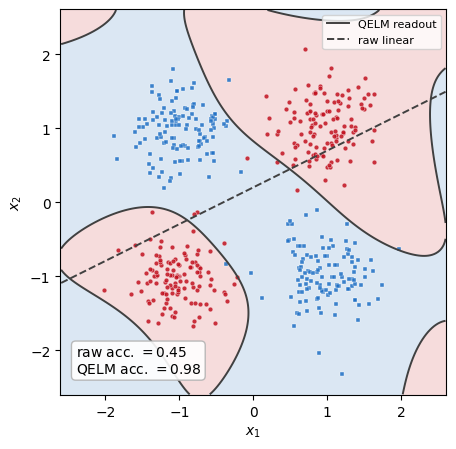

In [8]:
GRID_LIM, GRID_N = 2.6, 200
g = np.linspace(-GRID_LIM, GRID_LIM, GRID_N)
gx, gy = np.meshgrid(g, g)
grid_pts = np.column_stack([gx.ravel(), gy.ravel()])

F_grid = qelm_features(grid_pts, N, U, COLS, W, ALPHA)
prob_qelm = qelm_clf.predict_proba(F_grid)[:, 1].reshape(gx.shape)
prob_raw = raw_clf.predict_proba(grid_pts)[:, 1].reshape(gx.shape)

REGION = ListedColormap(["#dbe7f3", "#f6dcdc"])
fig, ax = plt.subplots(figsize=(4.9, 4.6))
ax.pcolormesh(g, g, (prob_qelm > 0.5).astype(int), cmap=REGION, shading="auto")
ax.contour(g, g, prob_qelm, levels=[0.5], colors="0.25", linewidths=1.4)
ax.contour(g, g, prob_raw, levels=[0.5], colors="0.25", linestyles="--", linewidths=1.4)
for lab, col, mk in [(1, C_POS, "o"), (0, C_NEG, "s")]:
    m = y == lab
    ax.scatter(XY[m, 0], XY[m, 1], s=12, color=col, marker=mk,
               edgecolors="white", linewidths=0.3, alpha=0.85)
ax.legend(handles=[Line2D([0], [0], color="0.25", lw=1.4, label="QELM readout"),
                   Line2D([0], [0], color="0.25", lw=1.4, ls="--", label="raw linear")],
          loc="upper right", fontsize=8)
ax.text(0.04, 0.05, f"raw acc. $= {acc_raw:.2f}$\nQELM acc. $= {acc_qelm:.2f}$",
        transform=ax.transAxes, va="bottom",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9))
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$"); ax.set_aspect("equal", "box")
plt.tight_layout(); plt.show()

## Conclusion

The QELM readout wraps its decision boundary around all four clusters and recovers
the checkerboard, while the raw linear model is confined to a single straight cut
that gets XOR half right. The fixed quantum feature map made a non-separable problem
linearly separable, and the ablation pins the credit precisely: with the same
encoding and the same linear readout, it is the fixed scrambling unitary that
supplies the nonlinear $x_1 x_2$ feature. This is the QELM at its cleanest, the
physics learns the representation, and only a hyperplane is fit on top.